In [1]:
import pandas as pd     # 数据表
import numpy as np     # 数组
import re     # 正则表达式
import jieba     # 中文分词
import matplotlib.pyplot as plt     # 画图
from gensim.models import Word2Vec     # 训练词嵌入模型
# import gensim.downloader as api     # 导入云端的已训练好的词向量
from gensim.models import KeyedVectors     # 加载自己本地个性化的已训练好的词向量
from sklearn.metrics.pairwise import cosine_similarity     # 计算向量之间的余弦相似度
from sklearn.decomposition import PCA     # 语义空间降维，用于展示词语在二维空间的相对位置

In [2]:
df = pd.read_excel('三年级.xlsx').astype(str)
df[:20]

,序号,年级,作文题目,作文id,作文标题,开头score,结尾score,审题score,立意score,详略score,条理score,选材score,想象score,思想score
0,1,3,我的植物朋友,612,我爱仙人掌,7.5,8.5,9.6,10.0,9.5,nan,nan,nan,nan
1,2,3,奇妙的想象,620,“我”的梦想,8.5,8.5,8.7,8.1,9.0,nan,nan,8.91,nan
2,3,3,看图画写作文,616,放风筝,8.5,7.0,6.633333333,7.2,6.7,nan,nan,nan,nan
3,4,3,奇妙的想象,620,小水滴的梦想,9.0,4.8,7.586666667,8.3,7.1,nan,nan,8.91,nan
4,5,3,写一个熟悉的人,622,我们班的“双子星”同学,8.5,8.75,8.693333333,8.4,8.6,nan,8.65,nan,nan
5,6,3,有趣的节日活动,614,贴春联,9.0,9.04,9.6,7.75,9.0,nan,nan,nan,nan
6,7,3,我做了一项小实验,618,神奇的纸桥,8.25,8.0,9.6,7.75,9.0,nan,nan,nan,nan
7,8,3,奇妙的想象,620,滚来滚去的小土豆,8.5,8.0,10.0,7.7,9.0,nan,nan,8.6,nan
8,9,3,看图画写作文,616,放风筝,8.0,9.04,9.84,7.2,9.0,nan,nan,nan,nan
9,10,3,我的植物朋友,612,美丽的油菜花,8.0,5.5,9.52,9.5,9.5,nan,nan,nan,nan


In [4]:
def remove_nums(text):
    nonums = re.sub('[^\u4e00-\u9fa5]+', '', text)
    return nonums
test = df['作文标题'][8]
remove_nums(test)

'放风筝'

In [5]:
# 加载中文停用词词典，可个性化设置
stopwords = open('stopwords.txt', encoding = 'utf-8').read()

def clean_text(text):
    words = jieba.lcut(text)
    words = [w for w in words if w not in stopwords]
    return ' '.join(words)
test = df['作文标题'][8]
clean_text(test)

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/kk/ylyfvmrj6zv853wrvp3s_0180000gn/T/jieba.cache
Loading model cost 0.346 seconds.
Prefix dict has been built successfully.


'放风筝'

In [6]:
df['作文标题分词'] = df['作文标题'].apply(remove_nums)
df['作文标题分词'] = df['作文标题分词'].apply(clean_text)
df.head()

,序号,年级,作文题目,作文id,作文标题,开头score,结尾score,审题score,立意score,详略score,条理score,选材score,想象score,思想score,作文标题分词
0,1,3,我的植物朋友,612,我爱仙人掌,7.5,8.5,9.6,10.0,9.5,nan,nan,nan,nan,爱 仙人掌
1,2,3,奇妙的想象,620,“我”的梦想,8.5,8.5,8.7,8.1,9.0,nan,nan,8.91,nan,梦想
2,3,3,看图画写作文,616,放风筝,8.5,7.0,6.633333333,7.2,6.7,nan,nan,nan,nan,放风筝
3,4,3,奇妙的想象,620,小水滴的梦想,9.0,4.8,7.586666667,8.3,7.1,nan,nan,8.91,nan,小水滴 梦想
4,5,3,写一个熟悉的人,622,我们班的“双子星”同学,8.5,8.75,8.693333333,8.4,8.6,nan,8.65,nan,nan,班 双子星 同学


In [7]:
import pandas as pd #数据表
import numpy as np #数组运算
import nltk #英文语料处理
import re #正则表达式（用于数据清洗）
import matplotlib.pyplot as plt #画图
from wordcloud import WordCloud #词云图
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
from sklearn.feature_extraction.text import CountVectorizer

In [8]:
text=list(df['作文标题分词'])[:100]
text=" ".join(text)
lemmatizer=WordNetLemmatizer()
#转换为小写
text=text.lower()
#移除URL
text=re.sub(r'http\S+','',text)
text
#初始化CounVectorizer
vectorizer=CountVectorizer()
#将文本数据转换为词袋特征矩阵
X=vectorizer.fit_transform(df['作文标题分词'])
#展示特征矩阵的形状
print('词袋特征矩阵的形状:',X.shape)
#展示词袋模型中的所有特征词
print('特征词列表:',vectorizer.get_feature_names_out()[:20])

词袋特征矩阵的形状: (30282, 3087)
特征词列表: ['一个' '一个个' '一件' '一位' '一元' '一写' '一击入' '一刻' '一动不如一静' '一双' '一只' '一名' '一团'
 '一场' '一块' '一头' '一家' '一岁' '一年' '一年一度']


In [9]:
#获取词汇表
feature_words=vectorizer.get_feature_names_out()
#计算词频
word_freq=dict(zip(feature_words,X.sum(axis=0).A1))

In [10]:
sorted(word_freq.items(),key=lambda X: X[1],reverse=True)
items = list(word_freq.items())
items.sort(key=lambda x:x[1], reverse=True)
for i in range(100):
    word, count = items[i]
    print("{0:<100}{1:>5}".format(word,count))
print ('已统计数量排前100的词')

放风筝                                                                                                  7389
小树                                                                                                   4117
梦想                                                                                                   3054
朋友                                                                                                   1800
植物                                                                                                   1569
春节                                                                                                   1356
火山爆发                                                                                                 1304
实验                                                                                                   1275
大熊猫                                                                                                  1132
心思                                            

In [11]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
 
#for font in font_manager.fontManager.ttflist:
    # 查看字体名以及对应的字体文件名
   # print(font.name, '-', font.fname)

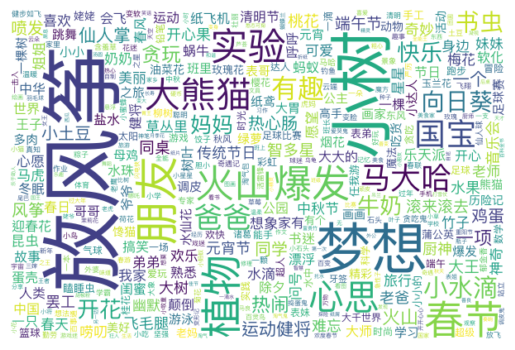

In [15]:
# 根据词袋模型分析结果绘制词云图
from wordcloud import WordCloud
import matplotlib.pyplot as plt 

wordcloud = WordCloud(
    font_path='/System/Library/Fonts/PingFang.ttc',  # 指定中文字体文件路径
    background_color='white',  # 设置背景颜色
    width=600,
    height=400,
    max_words=400,  # 设置最大显示的词数
    max_font_size=100  # 设置字体最大值
).generate_from_frequencies(word_freq)

# 显示词云图
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig('wordcloud_三年级作文标题.png', dpi=300)
plt.show()

In [16]:
from gensim.test.utils import common_texts
common_texts

[['human', 'interface', 'computer'],
 ['survey', 'user', 'computer', 'system', 'response', 'time'],
 ['eps', 'user', 'interface', 'system'],
 ['system', 'human', 'system', 'eps'],
 ['user', 'response', 'time'],
 ['trees'],
 ['graph', 'trees'],
 ['graph', 'minors', 'trees'],
 ['graph', 'minors', 'survey']]

In [17]:
corpus=df['作文标题分词'].apply(lambda X: X.split()).tolist()#切分词语
for document in corpus[:10]:
    print(document[:20])

['爱', '仙人掌']
['梦想']
['放风筝']
['小水滴', '梦想']
['班', '双子星', '同学']
['春联']
['神奇', '纸桥']
['滚来滚去', '小土豆']
['放风筝']
['美丽', '油菜花']


In [18]:
#训练词嵌入模型
from gensim.models import Word2Vec
corpus=df['作文标题分词'].apply(lambda X: X.split()).tolist()#切分词语
model=Word2Vec(
    corpus, #训练语料
    window=5,#训练算法考虑的当前词语与预测词语在一个句子中的最大距离（窗口大小）
    vector_size=300,#自定义训练向量维度
    min_count=1,#忽略所有总频数低于这个值的词语
    #workers=4,#用于训练的线程数
    epochs=5)#迭代

#保存训练好的模型
model.save('word2vec_三年级作文标题.model')

In [19]:
word_list=model.wv.index_to_key#获取词汇表
word_vectors=model.wv[word_list]#获取词向量

#打印词汇表和对应的词向量
for word,vector in list(zip(word_list,word_vectors))[:5]:
    print(f'{word}:{vector}'[:20])

放风筝:[-3.79678747e-03
小树:[-0.02529097  0.0
梦想:[ 1.61009040e-02 
朋友:[-0.01707021  0.0
植物:[ 0.01037853  0.0


In [20]:
#检查嵌入模型中任意两个词向量的余弦相似度，即语义接近性
#余弦相似度的取值介于[-1，1]之间，-1表示语义完全相反，1表示语义完全相同，0表示毫无关系
#model.sv.similarity这个函数与np.dot(vector1,vector2)/(np.linalg.norm(vector1)*np.linalg.norm(vector2))输出的结果一样
print(model.wv.similarity('小树', '放风筝'))
print(model.wv.similarity('梦想', '放风筝'))
print(model.wv.similarity('朋友', '放风筝'))
print(model.wv.similarity('朋友', '小树'))
print(model.wv.similarity('朋友', '梦想'))
print(model.wv.similarity('小树', '梦想'))

0.81210357
0.8368552
0.86301786
0.6411946
0.70233417
0.61814123


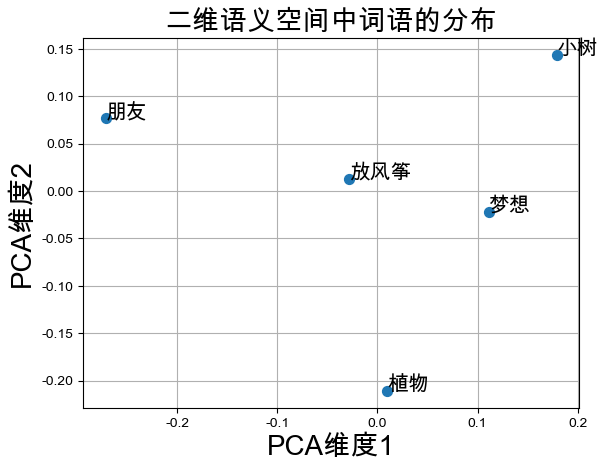

In [21]:
# 可视化

words = ['小树', '放风筝', '梦想', '朋友','植物']
vectors = [model.wv[word] for word in words]

from sklearn.decomposition import PCA     # 语义空间降维，用于展示词语在二维空间的相对位置

# 使用PCA进行降维
pca = PCA(n_components = 2)
pca_result = pca.fit_transform(vectors)

import matplotlib.pyplot as plt     # 画图

# 绘制四个词语在二维空间的相对位置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.figure()

# 取PCA降维结果中所有行的第一列和第二列数据绘制散点图，设置点的大小为50
plt.scatter(pca_result[:, 0], pca_result[:, 1], s = 50)

for i, word in enumerate(words):
    plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]), fontsize = 15)

plt.xlabel('PCA维度1', fontsize = 20)
plt.ylabel('PCA维度2', fontsize = 20)
plt.title('二维语义空间中词语的分布', fontsize = 20)
plt.grid(True)
plt.show()

In [22]:
import gensim
from gensim import corpora
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # To ignore all warnings that arise here to enhance clarity

from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel

In [23]:
from gensim.models import Word2Vec
txt=df['作文标题分词'].apply(lambda X: X.split()).tolist()#切分词语

In [24]:
dictionary = corpora.Dictionary(txt)  # 构建词典
corpus = [dictionary.doc2bow(text) for text in txt]  #表示为第几个单词出现了几次

In [25]:
ldamodel = LdaModel(corpus, num_topics=10, id2word = dictionary, passes=30,random_state = 1)   #分为10个主题
num_topics=10
print(ldamodel.print_topics(num_topics=num_topics, num_words=15)[:20])  #每个主题输出15个单词

[(0, '0.129*"小水滴" + 0.117*"牛奶" + 0.114*"开花" + 0.077*"贪玩" + 0.050*"同学" + 0.042*"大王" + 0.027*"开心果" + 0.026*"中秋节" + 0.022*"问号" + 0.021*"奶奶" + 0.015*"马虎" + 0.012*"颠倒" + 0.011*"旅行" + 0.009*"想" + 0.009*"书"'), (1, '0.286*"实验" + 0.151*"有趣" + 0.063*"一项" + 0.042*"一个" + 0.036*"同桌" + 0.036*"老爸" + 0.026*"弟弟" + 0.024*"音乐会" + 0.023*"水果" + 0.021*"星星" + 0.017*"爱" + 0.017*"躲" + 0.016*"草丛里" + 0.014*"水珠" + 0.009*"树叶"'), (2, '0.337*"春节" + 0.111*"快乐" + 0.075*"热闹" + 0.049*"风筝" + 0.048*"元宵节" + 0.040*"难忘" + 0.031*"心愿" + 0.023*"春天" + 0.018*"老师" + 0.015*"春日" + 0.012*"除夕" + 0.009*"春风" + 0.007*"飞" + 0.006*"呼呼" + 0.004*"枪械"'), (3, '0.151*"书虫" + 0.104*"妈妈" + 0.072*"火山" + 0.053*"喷发" + 0.051*"厨神" + 0.047*"端午节" + 0.035*"飞毛腿" + 0.022*"我家" + 0.021*"水滴" + 0.019*"姐姐" + 0.018*"妹妹" + 0.015*"书迷" + 0.012*"哥哥" + 0.010*"闺蜜" + 0.009*"水"'), (4, '0.804*"放风筝" + 0.058*"向日葵" + 0.013*"大树" + 0.010*"唠叨" + 0.010*"欢乐" + 0.007*"冬眠" + 0.006*"竹子" + 0.006*"清明节" + 0.005*"跳舞" + 0.004*"老妈" + 0.003*"学习" + 0.002*"王妈妈" + 0.002*"纸屑" + 0.002*"瞌睡虫" + 0

In [26]:
#计算困惑度
def perplexity(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=15))
    print(ldamodel.log_perplexity(corpus))
    return ldamodel.log_perplexity(corpus)

In [27]:
#计算coherence
def coherence(num_topics):
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word = dictionary, passes=30,random_state = 1)
    print(ldamodel.print_topics(num_topics=num_topics, num_words=10))
    ldacm = CoherenceModel(model=ldamodel, texts=txt, dictionary=dictionary, coherence='c_v')
    print(ldacm.get_coherence())
    return ldacm.get_coherence()

[(0, '0.137*"放风筝" + 0.077*"小树" + 0.058*"梦想" + 0.033*"朋友" + 0.029*"植物" + 0.026*"春节" + 0.024*"实验" + 0.022*"心思" + 0.022*"大熊猫" + 0.021*"火山爆发"')]
0.7275665586079484
[(0, '0.290*"放风筝" + 0.070*"朋友" + 0.062*"植物" + 0.054*"春节" + 0.045*"火山爆发" + 0.020*"小水滴" + 0.018*"牛奶" + 0.018*"快乐" + 0.018*"开花" + 0.016*"妈妈"'), (1, '0.147*"小树" + 0.109*"梦想" + 0.045*"实验" + 0.042*"心思" + 0.042*"大熊猫" + 0.033*"国宝" + 0.031*"马大哈" + 0.026*"爸爸" + 0.024*"有趣" + 0.020*"书虫"')]
0.7152465372827916
[(0, '0.125*"朋友" + 0.110*"植物" + 0.081*"火山爆发" + 0.036*"小水滴" + 0.032*"牛奶" + 0.031*"开花" + 0.028*"妈妈" + 0.021*"贪玩" + 0.018*"仙人掌" + 0.014*"厨神"'), (1, '0.089*"实验" + 0.082*"大熊猫" + 0.065*"国宝" + 0.047*"有趣" + 0.040*"书虫" + 0.037*"向日葵" + 0.031*"班" + 0.020*"一项" + 0.016*"热心肠" + 0.015*"同桌"'), (2, '0.294*"放风筝" + 0.166*"小树" + 0.123*"梦想" + 0.055*"春节" + 0.047*"心思" + 0.035*"马大哈" + 0.030*"爸爸" + 0.018*"快乐" + 0.012*"热闹" + 0.011*"火山"')]
0.6868719564988574
[(0, '0.156*"朋友" + 0.137*"植物" + 0.100*"火山爆发" + 0.044*"小水滴" + 0.040*"牛奶" + 0.039*"开花" + 0.026*"贪玩" + 0.022*

0.6572943586432783
[(0, '0.157*"妈妈" + 0.077*"同学" + 0.076*"厨神" + 0.065*"大王" + 0.045*"奇妙" + 0.041*"中秋节" + 0.033*"奶奶" + 0.025*"旅行" + 0.024*"春日" + 0.020*"蚂蚁"'), (1, '0.213*"有趣" + 0.176*"实验" + 0.167*"向日葵" + 0.051*"老爸" + 0.042*"飞毛腿" + 0.037*"弟弟" + 0.033*"音乐会" + 0.033*"水果" + 0.027*"问号" + 0.020*"水珠"'), (2, '0.384*"春节" + 0.127*"快乐" + 0.086*"热闹" + 0.056*"风筝" + 0.055*"元宵节" + 0.046*"难忘" + 0.020*"愿望" + 0.013*"除夕" + 0.011*"春天" + 0.008*"飞"'), (3, '0.233*"马大哈" + 0.198*"爸爸" + 0.154*"书虫" + 0.048*"端午节" + 0.025*"星星" + 0.023*"我家" + 0.020*"躲" + 0.020*"姐姐" + 0.020*"草丛里" + 0.015*"书迷"'), (4, '0.911*"放风筝" + 0.012*"唠叨" + 0.006*"清明节" + 0.005*"包" + 0.004*"老妈" + 0.003*"调皮" + 0.003*"学习" + 0.003*"多肉" + 0.002*"粽子" + 0.002*"太阳"'), (5, '0.243*"火山爆发" + 0.097*"牛奶" + 0.094*"开花" + 0.094*"班" + 0.051*"运动健将" + 0.048*"热心肠" + 0.038*"智多星" + 0.035*"罢工" + 0.033*"手" + 0.028*"传统节日"'), (6, '0.170*"小水滴" + 0.101*"贪玩" + 0.072*"同桌" + 0.061*"鸡蛋" + 0.041*"梦" + 0.036*"乐天派" + 0.027*"水滴" + 0.025*"家有" + 0.024*"浮" + 0.022*"神奇"'), (7, '0.316*"大熊猫

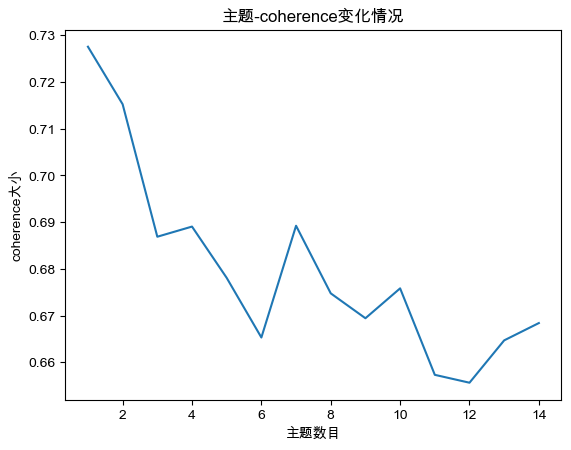

In [28]:
# 绘制困惑度折线图
x = range(1,15)
# z = [perplexity(i) for i in x]
y = [coherence(i) for i in x]
plt.plot(x, y)
plt.xlabel('主题数目')
plt.ylabel('coherence大小')
plt.rcParams['font.sans-serif']=['Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus']=False
plt.title('主题-coherence变化情况')
plt.show()

In [29]:
lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes = 30,random_state=1)
topic_list=lda.print_topics()
print(topic_list[:20])

[(0, '0.190*"朋友" + 0.167*"植物" + 0.123*"火山爆发" + 0.054*"小水滴" + 0.032*"贪玩" + 0.027*"仙人掌" + 0.017*"罢工" + 0.017*"手" + 0.015*"树" + 0.011*"中秋节"'), (1, '0.153*"实验" + 0.081*"有趣" + 0.053*"班" + 0.034*"一项" + 0.027*"热心肠" + 0.026*"同桌" + 0.023*"同学" + 0.021*"智多星" + 0.020*"大王" + 0.019*"老爸"'), (2, '0.297*"小树" + 0.221*"梦想" + 0.098*"春节" + 0.085*"心思" + 0.032*"快乐" + 0.022*"热闹" + 0.017*"运动健将" + 0.014*"元宵节" + 0.012*"难忘" + 0.011*"风筝"'), (3, '0.109*"马大哈" + 0.093*"爸爸" + 0.073*"书虫" + 0.050*"妈妈" + 0.035*"火山" + 0.026*"喷发" + 0.024*"一个" + 0.023*"端午节" + 0.015*"弟弟" + 0.014*"鸡蛋"'), (4, '0.528*"放风筝" + 0.084*"大熊猫" + 0.067*"国宝" + 0.038*"向日葵" + 0.033*"牛奶" + 0.032*"开花" + 0.014*"厨神" + 0.013*"小土豆" + 0.011*"滚来滚去" + 0.009*"迷"')]


In [30]:
result_list =[]
for i in lda.get_document_topics(corpus)[:]:
    listj=[]
    for j in i:
        listj.append(j[1])
    bz=listj.index(max(listj))
    result_list.append(i[bz][0])
print(result_list[:20])

[0, 2, 4, 2, 1, 0, 1, 4, 4, 0, 3, 1, 4, 0, 4, 2, 0, 0, 3, 2]


In [31]:
import pyLDAvis.gensim
pyLDAvis.enable_notebook()
data = pyLDAvis.gensim.prepare(lda, corpus, dictionary)
pyLDAvis.save_html(data, '三年级作文标题.html')